In [1]:
using Pkg; Pkg.activate("..")
# Pkg.instantiate()

using Dates
using Interpolations

using NCDatasets
using PyPlot


  Activating project at `~/Projects/ASTRAL/soundings`


In [2]:
using PyCall
using PyCall: PyObject

# PyObject method interprets Array{Union{T,Missing}} as a
# numpy masked array.
# This allows for plotting with missing values.
function PyObject(a::Array{Union{T,Missing},N}) where {T,N}
    numpy_ma = PyCall.pyimport("numpy").ma
    pycall(numpy_ma.array, Any, coalesce.(a,zero(T)), mask=ismissing.(a))
end

PyObject

In [3]:
module VaporSat

using ForwardDiff

export qs, dqsdT
export Twet_autodiff

# constants
Cp = 1005.7  # from my Davies-Jones function, was 1005.
Cpv = 1870.0 # J/kg/K
Cw  = 4190.0
L0 = 2.501e6 # J/kg

C = 273.15 # K
Rd = 287.04
Rv = 461.5
RdoRv=Rd/Rv

"latent heat of water vapor"
LvK(TempK) = L0 + (Cpv-Cw) * (TempK-273.0)

# functions
"""
es(T,p) = is saturation vapor pressure based on Wexler's formula,
with enhancement factor for moist air rather than water vapor.
The enhancement factor requires a pressure.
T [degrees C], p [Pa] (note the reversed input order), es [Pa]
Calling with optional keywords changes the units and
ignores the positional arguments.
es(T,p; TK=tk[Kelvin], P=pr[hPa])
From A. L. Buck 1981: JAM, 20, 1527-1532.
SPdeS 7 July 2004
"""
function es(T,p=1e5; P=p*1e-2)
    esat = 1e2 * 6.1121*(1.0007 + 3.46e-8*P)*exp((17.502*T)/(240.97 + T)) # convert es to Pa
end

# supply TK [Kelvin] by keyword, ignores positional T!!
function es(T,p=1e5; TK=T+C, P=p*1e-2)
    T = TK - C
    esat = 1e2 * 6.1121*(1.0007 + 3.46e-8*P)*exp((17.502*T)/(240.97 + T)) # convert es to Pa
end

"""
qs(p,T) is saturation specific humidity based on Wexler's formula for es
with enhancement factor (see es.m).
p [Pa], T [degrees C], qs [kg/kg]
From A. L. Buck 1981: JAM, 20, 1527-1532.
SPdeS 7 July 2004
"""
qs(p,T) = RdoRv*es(T,p) / (p + (RdoRv-1)*es(T,p))

"dqsdT(p,T[C]) derivative of qs with respect to T at p,T by autodiff of Bolton's qs"
dqsdT(p,T) = ForwardDiff.derivative(t -> qs(p,t), T)
# assumes isobaric

# wet bulb temperature methods
# for approximating the evap process

"General single Newton iteration to update x toward f(x) = fhat for a univariate function f"
updatex(f, x, fhat=0) = x + (fhat-f(x)) / ForwardDiff.derivative(f, x)

"""
Twet_autodiff(T[K], q[kg/kg], p[Pa]; niter=2) wet bulb temperature using Newton's method
for target specific humidity q[kg/kg]. Uses automatic differntiation.
"""
function Twet_autodiff(T, q, p; niter=2)
    f(t) = (t - T) + LvK((T+t)/2)/Cp * (qs(p,t-C) - q)
    t=T
    for i in 1:niter
        t = updatex(f, t, 0)
    end
    t
end
# 2 iterations converges to ~0.001 K

# call as...
# q = rh*qs(pa, Ta)
# Twet_autodiff(Ta, rh*qs(pa, Ta-C), pa) 

end # module VaporSat

using .VaporSat

ArgumentError: ArgumentError: Package ForwardDiff [f6369f11-7733-5829-9624-2563aa707210] is required but does not seem to be installed:
 - Run `Pkg.instantiate()` to install all recorded dependencies.


In [4]:
# thermo functions

"Exner function = T/θ = (p/p0)^(Rd/Cp)"
Exner(p; p0=1000.0) = (p/p0)^0.287
Exner(p, qv; p0=1000.0) = (p/p0) ^ ((Rd/Cp) * (1 - 0.28*qv))

"potential temperature [K] = theta(T[K], p[hPa])"
theta(T, p) = T/Exner(p)
theta(T, p, qv) = T/Exner(p, qv)

theta (generic function with 2 methods)

In [5]:
# data processing functions

"convert filename to datetime"
function extract_datetime(filename::String)
    m = match(r"(\d{8})_(\d{4})", filename)
    if m !== nothing
        date_str = m.captures[1]  # "20250704"
        time_str = m.captures[2]  # "0000"
        return DateTime(date_str * time_str, "yyyymmddHHMM")
    else
        error("No valid datetime found in filename.")
    end
end

# Interpolation methods
# Pressure is irregular and different for each sounding time.

function isvalid(x)
    !ismissing(x) && isfinite(x)
end
function valid_mask(arrays::Tuple)
    map( t -> all(isvalid, t), zip(arrays...))
end
function valid_inds(arrays::Tuple)
    findall(t -> all(isvalid, t), zip(arrays...))
end

# interpolation functions
function itp_sparse(x::Vector, p::Vector)
    # knot-vectors must be unique and sorted in increasing order
    ind = sortperm(p)
    ii = valid_mask( (p[ind],) )
    inter = interpolate( (p[ind][ii],), x[ind][ii], Gridded(Linear()) )
    extrapolate( inter, NaN )
end

"interpolation function that filters missing data from the input sounding before interpolating."
function itp(x::Vector, p::Vector)
    # knot-vectors must be unique and sorted in increasing order
    ind = sortperm(p)
    pt = p[ind]
    xt = x[ind]
    ii = valid_mask((pt, xt)) # .& .!ismissing.(p[ind] .+ x[ind])
    inter = interpolate( (pt[ii],), xt[ii], Gridded(Linear()) )
    extrapolate( inter, NaN )
end

# pressure levels to interploate to
dp = 50.0
plevs = 1000.0:-dp:0.0

"rectangular interval averaging onto a decreasing pressure coordinate"
function pavg(x::Vector, p::Vector; plevs=plevs)
    s1 = zeros(Float64, size(plevs))
    # s2 = zeros(Float64, size(p))
    ns = zeros(Float64, size(plevs))
    
    for i in eachindex(p)
        j = findfirst(x -> x < p[i], plevs) # j indexes plevs
        if !isnothing(j)
            s1[j] += isfinite(x[i]) ? x[i] : 0
            # s2[j] += x[i]^2
            ns[j] += 1.0*isfinite(x[i])
        end
    end
    
    s1 ./ ns # mean
end


pavg

In [6]:
# files
amini_dir = "../data/uwyo/aminidivi/"
amini_files = filter(x -> startswith(x,"aminidivi") && endswith(x,".nc"), readdir(amini_dir))
dts = extract_datetime.(amini_files)

# test
f = amini_files[1]
ds = NCDatasets.Dataset(joinpath(amini_dir, f))
temperature = ds["temperature"][:]

Base.IOError: IOError: readdir("../data/uwyo/aminidivi/"): no such file or directory (ENOENT)

In [ ]:
"Read and fill temperature, spechum, u_wind, v_wind from Aminidivi files."
function read_data!( temperature, spechum, u_wind, v_wind; pavg = (t,p) -> itp(t, p).(plevs) )
    for (i, f) in enumerate(amini_files)     # loop over files and extract data
        dt = extract_datetime(f)
        # println("Processing file: $f with datetime: $dt")
        ds = NCDatasets.Dataset(joinpath(amini_dir, f))
        
        # Extract variables
        pressure  = ds["pressure"][:]
        if sum(isfinite.(pressure)) > 3
            dewpoint  = ds["dewpoint"][:]

            temperature[:,i] .= pavg( ds["temperature"][:],  pressure) # C
            spechum[    :,i] .= pavg( qs.(1e2*pressure, dewpoint),  pressure)
            u_wind[     :,i] .= pavg( ds["u_wind"][:], pressure)

            # hack v wind if truncated from data set
            wind_direction = ds["direction"][:]
            wind_speed = ds["speed"][:]
            v_wind[     :,i] .= pavg( -cosd.(wind_direction) .* wind_speed, pressure )
        end
    end
end


┌ Warning: Duplicated knots were deduplicated. Use Interpolations.deduplicate_knots!(knots) explicitly to avoid this warning.
│   k1 = Float32[45.1, 50.0, 55.9, 66.0, 70.0, 75.3, 77.8, 81.3, 84.6, 85.0, 92.4, 100.0, 105.0, 126.5, 127.0, 150.0, 157.0, 163.3, 190.0, 200.0, 207.6, 246.0, 247.0, 248.0, 250.0, 252.0, 257.0, 260.2, 262.0, 264.0, 265.0, 267.0, 268.0, 300.0, 322.7, 342.0, 359.0, 376.0, 385.0, 396.8, 400.0, 420.0, 438.0, 484.0, 484.0, 496.0, 500.0, 506.0, 522.9, 539.0, 564.4, 576.0, 586.2, 588.0, 608.7, 612.0, 622.0, 629.0, 631.9, 650.0, 655.8, 673.0, 693.0, 700.0, 705.9, 715.0, 732.0, 745.0, 757.0, 759.1, 786.8, 815.6, 850.0, 875.8, 907.2, 925.0, 939.4, 972.5, 984.0, 998.0, 1000.0, 1006.0, 1007.0]
└ @ Interpolations /Users/deszoeks/.julia/packages/Interpolations/MbXSq/src/gridded/gridded.jl:81
┌ Warning: Duplicated knots were deduplicated. Use Interpolations.deduplicate_knots!(knots) explicitly to avoid this warning.
│   k1 = Float32[45.1, 50.0, 55.9, 66.0, 70.0, 75.3, 77.8, 8

21×435 Matrix{Union{Missing, Float64}}:
 300.15   299.55   299.75   299.55   …  301.55   301.75   300.15   301.55
 300.168  301.85   300.095  301.252     301.99   301.676  300.84   301.687
 305.967  307.557  302.245  306.354     303.01   303.223  302.345  303.05
 309.452  309.662  307.357  308.614     304.633  305.68   304.633  305.261
 309.613  310.595  307.818  309.547     307.96   308.01   306.678  307.907
 312.27   311.084  309.808  310.371  …  311.546  311.613  310.636  310.453
 314.557  313.449  315.0    316.107     315.0    314.778  313.892  314.778
 319.675  317.22   317.697  318.347     318.109  318.301  316.962  317.311
 323.29   323.298  321.467  319.58      320.796  321.301  319.827  319.719
 326.233  326.324  323.258  321.933     323.787  324.669  322.862  323.526
   ⋮                                 ⋱                             
 337.751  337.751  334.89   331.508     335.93   336.711  335.67   337.491
 343.377  341.065  339.773  341.161     339.761  339.468  338.512  33

In [ ]:
# read sounding data from local disk

# allocate arrays for the variables
nit() = Matrix{Union{Float64, Missing}}(missing, length(plevs), length(amini_files))
temperature = nit()
spechum     = nit()
u_wind      = nit()
v_wind      = nit()

read_data!( temperature, spechum, u_wind, v_wind; pavg = (t,p) -> itp(t, p).(plevs) )
th = theta.(temperature.+273.15, plevs)

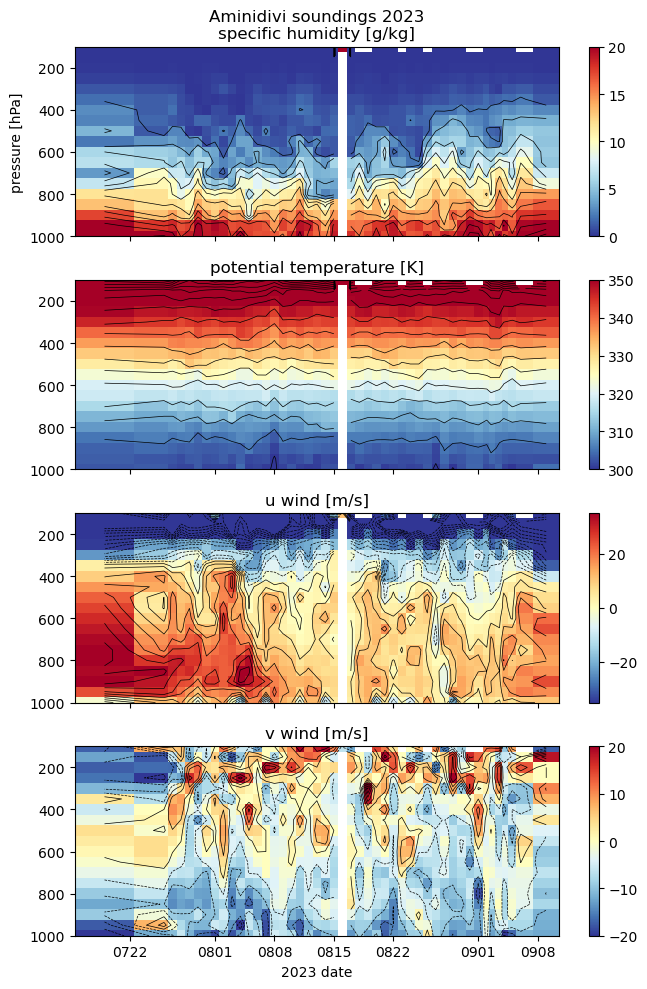

In [69]:
fit = findall( DateTime(2023,1,1) .<= dts .<= DateTime(2023,12,31) )




clf()
formatter = PyPlot.matplotlib.dates.DateFormatter("%m%d")
fig, axs = subplots(4,1, figsize=(7,10), sharex=true)
for ax in axs
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(formatter)
end

ax=axs[1]
pc = ax.pcolormesh(dts[fit], plevs, 1e3*spechum[:,fit], vmin=0, vmax=20, cmap=PyPlot.cm.RdYlBu_r, shading="auto")
colorbar(pc)
cr = ax.contour(dts[fit], plevs, 1e3*spechum[:,fit], levels=0:2:24, colors="k", linewidths=0.5)
ax.set_ylabel("pressure [hPa]")
ax.set_title("Aminidivi soundings 2023\nspecific humidity [g/kg]")

ax=axs[2]
pc = ax.pcolormesh(dts[fit], plevs, th[:,fit], vmin=300, vmax=350, cmap=PyPlot.cm.RdYlBu_r, shading="auto")
colorbar(pc)
cr = ax.contour(dts[fit], plevs, th[:,fit], levels=295:5:400, colors="k", linewidths=0.5)
ax.set_title("potential temperature [K]")

ax=axs[3]
pc = ax.pcolormesh(dts[fit], plevs, u_wind[:,fit], vmin=-35, vmax=35, cmap=PyPlot.cm.RdYlBu_r, shading="auto")
colorbar(pc)
cr = ax.contour(dts[fit], plevs, u_wind[:,fit], levels=-60:5:60, colors="k", linewidths=0.5)
ax.set_title("u wind [m/s]")

ax=axs[4]
pc = ax.pcolormesh(dts[fit], plevs, v_wind[:,fit], vmin=-20, vmax=20, cmap=PyPlot.cm.RdYlBu_r, shading="auto")
colorbar(pc)
cr = ax.contour(dts[fit], plevs, v_wind[:,fit], levels=-60:5:60, colors="k", linewidths=0.5)
ax.set_title("v wind [m/s]")
ax.set_xlabel("2023 date")

for ax in axs
    ax.set_ylim(1000, 100)
end
tight_layout()
fmt = ["png", "pdf", "svg", "eps"]
[ savefig("amini_sond_2023.$f") for f in fmt ]

gcf()


In [ ]:
# plot one soundings
#=
    
    # Plotting
    fig, ax1 = subplots()
    ax1.plot(temperature, pressure, label="Temperature (K)", color="red")
    ax1.plot(dewpoint, pressure, label="Dewpoint (K)", color="blue")
    
    ax2 = ax1.twiny()
    ax2.plot(wind_speed, pressure, label="Wind Speed (m/s)", color="green")
    
    ax1.set_xlabel("Temperature / Dewpoint (K)")
    ax2.set_xlabel("Wind Speed (m/s)")
    ax1.set_ylabel("Pressure (hPa)")
    
    ax1.invert_yaxis()  # Invert y-axis for atmospheric profile
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")
    
    title_str = "Sounding at Aminidivi on $(dt)"
    plt.title(title_str)
    
    savefig(joinpath(amini_dir, "aminidivi_sounding_$(dt).png"))